# Understanding Toxicity Behaviour in the League of Legends Video Game

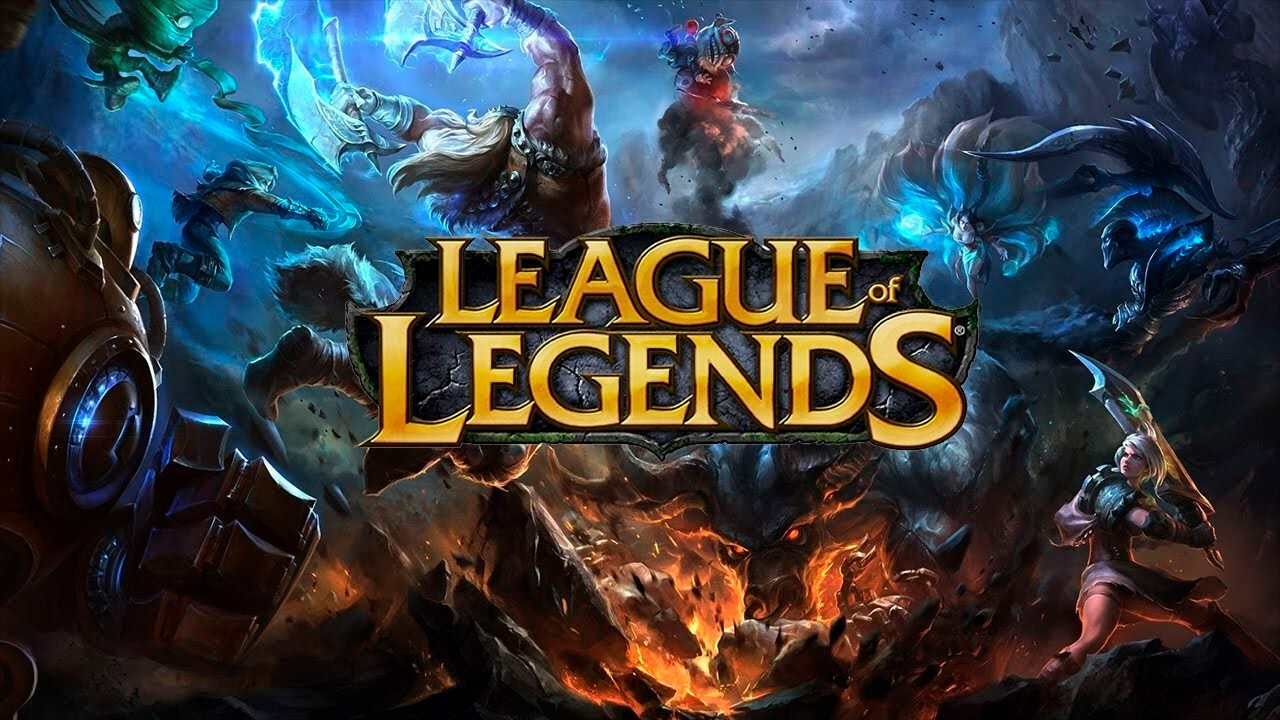

Source: https://www.instant-gaming.com/pl/9456-pobierz-league-of-legends-pc-game/?srsltid=AfmBOoqL7AXapiP7FBnAYtOD08S3M-PMo_DV3FdVGM0K6IcVxkwm1LMF

## Section 1: Introduction and Research Question

In the popular video game League of Legends, developed and published by Riot Games, players have to .... 5v5 each other ... Revenue can be generated from buying skins etc?

Toxic players are those who purposely do .... to make their team lose. 

Identifying toxic players is a difficult but important task for gaming companies like Riot Games, as players never self-identify as toxic and their behavior must be inferred from gameplay data. From a profit generation perspective, it is in the interest of gaming companies to understand toxicity as it significantly reduces player retention due to poor community health. Toxic players drive away other regular players, resulting in less retention, engagement, and spending from regular players. Therefore, with this business use-case in mind, we find it meaningful to understand toxicity in a popular team-based game like League of Legends, resulting in our formulation of the research questions listed below.

<font color="red"> NOTE: We can add some references on LoL reputation for having toxic players? or investing in researching in this field? any statements/articles they've published would support this use-case  <font color="black">

Research Questions:
1. What factors affect toxicity.....
2. ....


## Section 2: Prerequisites for Notebook

Please ensure necessary libraries are installed on your environment. Here is a list of less common libraries you will need to run this notebook:
1. ...


In [2]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.5/534.5 kB 10.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 9.9 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [datasets]/20 [datasets]ce-hub]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd 
import requests
from datasets import load_dataset

import time
import json

## Section 3: Data Preprocessing - Load Data

### 3.1: Load matches, participants, and events data from HuggingFace

Purpose:<font color="red"> write something!<font color="black"> 

Method: Load data using `datasets` library

Source: https://huggingface.co/datasets/gptilt/lol-basic-matches-challenger-10k

In [2]:
# Load token
token_file = open("ST445_Project_hf token.txt")
token_hf = token_file.read()

In [3]:
# Login to HuggingFace website
from huggingface_hub import login
login(token=token_hf)

In [4]:
# Load matches data
data_matches = load_dataset("gptilt/lol-basic-matches-challenger-10k", "matches")

# Get americas data and convert to pandas 
df_matches_amer = data_matches['region_americas'].to_pandas()

# Check data
df_matches_amer

,endOfGameResult,gameDuration,gameEndTimestamp,gameId,gameStartTimestamp,gameVersion,matchId,platformId,region,team_100_EPIC_MONSTER_KILL,...,team_200_horde_first,team_200_horde_kills,team_200_inhibitor_first,team_200_inhibitor_kills,team_200_riftHerald_first,team_200_riftHerald_kills,team_200_tower_first,team_200_tower_kills,tournamentCode,winner_team_id
0,GameComplete,1400,1745018960446,5269865992,1745017559681,15.8.675.10,NA1_5269865992,NA1,americas,3,...,False,0,False,0,False,0,False,2,,100
1,GameComplete,1524,1744589457829,5266494442,1744587933314,15.7.672.4034,NA1_5266494442,NA1,americas,2,...,True,5,True,1,False,0,False,8,,200
2,GameComplete,1782,1744585171830,5266444763,1744583389986,15.7.672.4034,NA1_5266444763,NA1,americas,2,...,True,1,False,0,False,0,False,2,,100
3,GameComplete,1939,1744582474913,5266408515,1744580535842,15.7.672.4034,NA1_5266408515,NA1,americas,1001,...,False,3,True,1,False,0,False,8,,200
4,GameComplete,930,1744576222010,5266355238,1744575291787,15.7.672.4034,NA1_5266355238,NA1,americas,1,...,False,0,False,0,False,0,True,3,,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,GameComplete,1306,1744695473229,1612786876,1744694166406,15.7.672.4034,LA1_1612786876,LA1,americas,1001,...,True,6,False,0,True,1,True,5,,200
3330,GameComplete,1517,1744690271585,1612758933,1744688754314,15.7.672.4034,LA1_1612758933,LA1,americas,1,...,True,3,True,2,False,0,False,7,,200
3331,GameComplete,1837,1744872208317,1613288313,1744870371493,15.8.673.8244,LA1_1613288313,LA1,americas,2,...,True,3,False,0,True,1,True,5,,100
3332,GameComplete,1902,1744776848623,1613000432,1744774946027,15.7.672.4034,LA1_1613000432,LA1,americas,3,...,False,0,True,2,False,0,False,10,,200


In [5]:
# Get columns from matches df
print("Matches Columns:")
print(df_matches_amer.columns)

Matches Columns:
Index(['endOfGameResult', 'gameDuration', 'gameEndTimestamp', 'gameId',
       'gameStartTimestamp', 'gameVersion', 'matchId', 'platformId', 'region',
       'team_100_EPIC_MONSTER_KILL', 'team_100_FIRST_BLOOD',
       'team_100_FIRST_TURRET', 'team_100_atakhan_first',
       'team_100_atakhan_kills', 'team_100_baron_first',
       'team_100_baron_kills', 'team_100_champion_first',
       'team_100_champion_kills', 'team_100_dragon_first',
       'team_100_dragon_kills', 'team_100_horde_first', 'team_100_horde_kills',
       'team_100_inhibitor_first', 'team_100_inhibitor_kills',
       'team_100_riftHerald_first', 'team_100_riftHerald_kills',
       'team_100_tower_first', 'team_100_tower_kills',
       'team_200_EPIC_MONSTER_KILL', 'team_200_FIRST_BLOOD',
       'team_200_FIRST_TURRET', 'team_200_atakhan_first',
       'team_200_atakhan_kills', 'team_200_baron_first',
       'team_200_baron_kills', 'team_200_champion_first',
       'team_200_champion_kills', 'team_20

In [ ]:
# Save to CSV for analysis
# df_matches_amer.to_csv("hf_matches.csv", index=False)
# print("Saved file: hf_matches.csv")

Saved file: hf_matches.csv


### 3.2: Load actual player behavior in games from Riot Games

Purpose:<font color="red"> write something!<font color="black"> 

Method: API Calls

Source: <font color="red"> insert link!<font color="black"> 

In [5]:
# Load API Key
api_file = open("ST445_Project_Riot API Key.txt")
RIOT_API_KEY = api_file.read()

In [ ]:
import requests
import time
from tqdm import tqdm

match_ids = df_matches_amer['matchId'].tolist()

def get_match_details(match_id, region='americas'):
    """Fetch match details from Riot API"""
    url = f"https://{region}.api.riotgames.com/lol/match/v5/matches/{match_id}"
    headers = {"X-Riot-Token": RIOT_API_KEY}
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 429:  # Rate limit
        time.sleep(2)
        return get_match_details(match_id, region)
    else:
        print(f"Error {response.status_code} for match {match_id}")
        return None

def extract_player_features(match_data):
    """Extract all white-label features for each player"""
    players = []
    
    info = match_data['info']
    match_id = match_data['metadata']['matchId']
    
    for participant in info['participants']:
        player = {
            'matchId': match_id,
            'puuid': participant['puuid'],
            
            # Performance stats
            'kills': participant['kills'],
            'deaths': participant['deaths'],
            'assists': participant['assists'],
            'kda': (participant['kills'] + participant['assists']) / max(participant['deaths'], 1),
            
            # Combat metrics
            'totalDamageDealtToChampions': participant['totalDamageDealtToChampions'],
            'totalDamageTaken': participant['totalDamageTaken'],
            
            # Economy
            'goldEarned': participant['goldEarned'],
            'totalMinionsKilled': participant['totalMinionsKilled'],
            'neutralMinionsKilled': participant['neutralMinionsKilled'],
            
            # Vision control
            'visionScore': participant['visionScore'],
            'wardsPlaced': participant['wardsPlaced'],
            'wardsKilled': participant['wardsKilled'],
            
            # Objectives
            'turretKills': participant['turretKills'],
            'inhibitorKills': participant['inhibitorKills'],
            'firstBloodKill': participant['firstBloodKill'],
            
            # Team contribution
            'killParticipation': participant.get('challenges', {}).get('killParticipation', 0),
            'teamDamagePercentage': participant.get('challenges', {}).get('teamDamagePercentage', 0),
            
            # Champion info
            'championName': participant['championName'],
            'championId': participant['championId'],
            
            # Game outcome
            'win': participant['win'],
            'gameDuration': info['gameDuration']
        }
        
        # Calculate per-minute stats
        duration_min = info['gameDuration'] / 60
        player['csPerMinute'] = (player['totalMinionsKilled'] + player['neutralMinionsKilled']) / duration_min
        player['goldPerMinute'] = player['goldEarned'] / duration_min
        player['visionScorePerMinute'] = player['visionScore'] / duration_min
        
        players.append(player)
    
    return players

# Collect data
all_players = []

for match_id in tqdm(match_ids):  # Start with 100 matches for testing
    match_data = get_match_details(match_id)
    
    if match_data:
        players = extract_player_features(match_data)
        all_players.extend(players)
    
    time.sleep(1.2)  # Rate limit: 20 requests per second, be safe with 1.2s

# Create DataFrame
df_players = pd.DataFrame(all_players)
df_players.to_csv("lol_player_features.csv", index=False)

print(f"\nCollected data for {len(df_players)} players across {len(df_players['matchId'].unique())} matches")
print(f"\nColumns: {df_players.columns.tolist()}")
print(f"\nSample:")
print(df_players.head())

### 3.3: Load champion data to get psychological features from Data Dragon json file

Purpose:<font color="red"> write something!<font color="black"> 

Method: Load json data from url 

Source: <font color="red"> insert link!<font color="black"> 

In [70]:
url = "https://ddragon.leagueoflegends.com/cdn/15.17.1/data/en_US/champion.json"

# Get json data
get_json = requests.get(url)
champion = get_json.json()

# Change data to pd format
df_champion = pd.DataFrame(champion['data'].values())

In [71]:
# Columns to expand as they contain multiple features
expand_columns = ['info', 'image', 'stats']


for c in expand_columns:
    # Expand column
    df_temp = df_champion[c].apply(pd.Series)

    # Add columns to main df_champion
    df_champion = pd.concat([df_champion, df_temp], axis=1)

    # Drop original column
    df_champion = df_champion.drop(c, axis=1)

In [72]:
# Display df_champion
df_champion

,version,id,key,name,title,blurb,tags,partype,attack,defense,...,hpregen,hpregenperlevel,mpregen,mpregenperlevel,crit,critperlevel,attackdamage,attackdamageperlevel,attackspeedperlevel,attackspeed
0,15.17.1,Aatrox,266,Aatrox,the Darkin Blade,Once honored defenders of Shurima against the ...,[Fighter],Blood Well,8,4,...,3.00,0.50,0.00,0.00,0.0,0.0,60.0,5.00,2.500,0.651
1,15.17.1,Ahri,103,Ahri,the Nine-Tailed Fox,Innately connected to the magic of the spirit ...,"[Mage, Assassin]",Mana,3,4,...,2.50,0.60,8.00,0.80,0.0,0.0,53.0,3.00,2.200,0.668
2,15.17.1,Akali,84,Akali,the Rogue Assassin,Abandoning the Kinkou Order and her title of t...,[Assassin],Energy,5,3,...,9.00,0.90,50.00,0.00,0.0,0.0,62.0,3.30,3.200,0.625
3,15.17.1,Akshan,166,Akshan,the Rogue Sentinel,"Raising an eyebrow in the face of danger, Aksh...","[Marksman, Assassin]",Mana,0,0,...,3.75,0.65,8.20,0.70,0.0,0.0,52.0,3.00,4.000,0.638
4,15.17.1,Alistar,12,Alistar,the Minotaur,Always a mighty warrior with a fearsome reputa...,"[Tank, Support]",Mana,6,9,...,8.50,0.85,8.50,0.80,0.0,0.0,62.0,3.75,2.125,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,15.17.1,Zeri,221,Zeri,The Spark of Zaun,"A headstrong, spirited young woman from Zaun's...",[Marksman],Mana,8,5,...,3.25,0.70,6.00,0.80,0.0,0.0,56.0,2.00,2.000,0.658
167,15.17.1,Ziggs,115,Ziggs,the Hexplosives Expert,"With a love of big bombs and short fuses, the ...",[Mage],Mana,2,4,...,6.50,0.60,8.00,0.80,0.0,0.0,55.0,3.10,2.000,0.656
168,15.17.1,Zilean,26,Zilean,the Chronokeeper,"Once a powerful Icathian mage, Zilean became o...","[Support, Mage]",Mana,2,5,...,5.50,0.50,11.35,0.80,0.0,0.0,52.0,3.00,2.130,0.658
169,15.17.1,Zoe,142,Zoe,the Aspect of Twilight,"As the embodiment of mischief, imagination, an...",[Mage],Mana,1,7,...,7.50,0.60,8.00,0.65,0.0,0.0,58.0,3.30,2.500,0.658


In [73]:
# Get columns from events df
print("Champion Columns:")
print(df_champion.columns)

Champion Columns:
Index(['version', 'id', 'key', 'name', 'title', 'blurb', 'tags', 'partype',
       'attack', 'defense', 'magic', 'difficulty', 'full', 'sprite', 'group',
       'x', 'y', 'w', 'h', 'hp', 'hpperlevel', 'mp', 'mpperlevel', 'movespeed',
       'armor', 'armorperlevel', 'spellblock', 'spellblockperlevel',
       'attackrange', 'hpregen', 'hpregenperlevel', 'mpregen',
       'mpregenperlevel', 'crit', 'critperlevel', 'attackdamage',
       'attackdamageperlevel', 'attackspeedperlevel', 'attackspeed'],
      dtype='object')


In [ ]:
# Save to CSV for analysis
# df_champion.to_csv("dd_champions.csv", index=False)
# print("Saved file: dd_champions.csv")

Saved file: dd_champions.csv


### 3.4: Web scrape champion-level metadata statistics from OP.GG

Purpose:<font color="red"> write something!<font color="black"> 

Method: 
Champion statistics are extracted by parsing embedded JSON data contained in the OP.GG statistics page HTML.
For each role (top, jungle, middle, bottom, support), the script identifies the JSON block corresponding to champion performance metrics and aggregates win rate, pick rate, ban rate, and usage indicators into a structured dataset.

Source: <font color="red"> insert link!<font color="black"> 
OP.GG - League of Legends Champion Statistics
https://op.gg/lol/statistics/champions

In [13]:
import requests
import time
import json
import pandas as pd

BASE_URL = "https://op.gg/lol/statistics/champions"
REGION = "na"  # Only used for the request parameters
POSITIONS = ["top", "jungle", "mid", "adc", "support"]

# Headers to mimic a real browser and avoid 403 Forbidden errors
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://op.gg/",
}

decoder = json.JSONDecoder()
all_rows = []

for pos in POSITIONS:
    print(f"\n=== Scraping Position: {pos} ===")

    res = requests.get(
        BASE_URL,
        params={"region": REGION, "position": pos, "tier": "challenger"},
        headers=headers,
        timeout=20,
    )
    res.raise_for_status()
    html = res.text

    # ------------------------------------------------------------
    # LOGIC: Locate all "[{" patterns in the HTML as potential candidates.
    # We attempt to parse (raw_decode) from those points and select the 
    # block that looks like the "Champion Statistics List."
    # ------------------------------------------------------------

    data = None
    idx = 0

    while True:
        start = html.find("[{", idx)
        if start == -1:
            break

        # Extract the chunk starting from "[{". We handle escaped quotes 
        # to ensure it's valid JSON format.
        chunk = html[start:].replace('\\"', '"')

        try:
            parsed, _ = decoder.raw_decode(chunk)
        except json.JSONDecodeError:
            idx = start + 2
            continue

        # Validate if the parsed JSON is the champion statistics list we want:
        # 1. It must be a list.
        # 2. It must not be empty.
        # 3. The first element should contain a 'champion' dictionary.
        # 4. It should contain win/pick/ban rates (supporting both snake_case and camelCase).
        if (
            isinstance(parsed, list)
            and len(parsed) > 0
            and isinstance(parsed[0], dict)
            and isinstance(parsed[0].get("champion"), dict)
        ):
            keys = set(parsed[0].keys())
            has_rates = (
                ("win_rate" in keys or "pick_rate" in keys or "ban_rate" in keys) or
                ("winRate" in keys or "pickRate" in keys or "banRate" in keys)
            )

            if has_rates:
                data = parsed
                print("Found champion stats block at start index:", start)
                print("Example data keys:", parsed[0].keys())
                break

        idx = start + 2

    if data is None:
        raise ValueError(f"Could not find champion stats JSON block for position={pos}.")

    # ------------------------------------------------------------
    # Process the extracted data into rows.
    # We account for both snake_case and camelCase naming conventions.
    # ------------------------------------------------------------
    for x in data:
        champ = x.get("champion", {})

        all_rows.append({
            "position": pos,
            "champion": champ.get("name"),
            "key": champ.get("key"),
            "games_played": x.get("play") or x.get("games") or x.get("gamesPlayed"),
            "kda": x.get("kda") or x.get("kdaRatio"),
            "win_rate": x.get("win_rate", x.get("winRate")),
            "pick_rate": x.get("pick_rate", x.get("pickRate")),
            "ban_rate": x.get("ban_rate", x.get("banRate")),
            "cs": x.get("cs"),
            "gold": x.get("gold"),
        })

    # Respectful pause to prevent rate limiting
    time.sleep(0.4)

# Create and organize the DataFrame
df = pd.DataFrame(all_rows)
df = df[
    ["position", "champion", "key",
     "games_played", "kda", "win_rate", "pick_rate", "ban_rate",
     "cs", "gold"]
]

display(df.head(10))
print("Total rows collected:", len(df))

 


=== Scraping Position: top ===
Found champion stats block at start index: 505898
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: jungle ===
Found champion stats block at start index: 505907
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: mid ===
Found champion stats block at start index: 505901
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: adc ===
Found champion stats block at start index: 505901
Example data keys: dict_keys(['champion', 'play', 'kda', 'kill', 'death', 'assist', 'win_rate', 'pick_rate', 'ban_rate', 'cs', 'gold'])

=== Scraping Position: support ===
Found champion stats block at start index: 470695
Example data keys: dict_keys(['champion

,position,champion,key,games_played,kda,win_rate,pick_rate,ban_rate,cs,gold
0,top,Lissandra,lissandra,6,2.33,16.666667,1.39,0.31,198.33,9889
1,top,Viktor,viktor,6,1.27,16.666667,1.34,0.35,207.67,12092
2,top,Syndra,syndra,6,1.89,16.666667,1.50,8.73,246.50,14188
3,top,Smolder,smolder,16,1.46,18.750000,1.50,0.86,197.19,11455
4,top,Orianna,orianna,5,1.40,20.000000,1.46,2.3,191.00,9231
5,top,Volibear,volibear,5,1.72,20.000000,1.53,$NaN,159.20,9395
6,top,Diana,diana,5,1.16,20.000000,1.64,4.7,171.80,9868
7,top,Gragas,gragas,16,1.66,25.000000,1.69,0.22,160.56,8569
8,top,Zilean,zilean,4,3.82,25.000000,1.75,10.59,228.50,11025
9,top,Kassadin,kassadin,4,2.33,25.000000,1.47,2.22,176.25,10478


Total rows collected: 459


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   position      459 non-null    object 
 1   champion      459 non-null    object 
 2   key           459 non-null    object 
 3   games_played  459 non-null    int64  
 4   kda           459 non-null    float64
 5   win_rate      459 non-null    float64
 6   pick_rate     459 non-null    float64
 7   ban_rate      459 non-null    object 
 8   cs            459 non-null    float64
 9   gold          459 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 36.0+ KB


In [15]:
df.isna().sum()

position        0
champion        0
key             0
games_played    0
kda             0
win_rate        0
pick_rate       0
ban_rate        0
cs              0
gold            0
dtype: int64

In [17]:
import numpy as np

# covert string NaN to np.nan for ban_rate
df["ban_rate"] = (
    df["ban_rate"]
    .replace(["NaN", "$NaN", "nan"], np.nan)
)

df["ban_rate"] = pd.to_numeric(df["ban_rate"], errors="coerce")

In [18]:
# 39 missivg values in ban_rate 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   position      459 non-null    object 
 1   champion      459 non-null    object 
 2   key           459 non-null    object 
 3   games_played  459 non-null    int64  
 4   kda           459 non-null    float64
 5   win_rate      459 non-null    float64
 6   pick_rate     459 non-null    float64
 7   ban_rate      420 non-null    float64
 8   cs            459 non-null    float64
 9   gold          459 non-null    int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 36.0+ KB


In [19]:
# Save to CSV for analysis
df.to_csv("opgg_champions_all_positions_challengers.csv", index=False)
print("Saved file: opgg_champions_all_positions_challengers.csv")

Saved file: opgg_champions_all_positions_challengers.csv


## Section 4: Data Preprocessing - Data Cleaning

In [27]:
# Display all columns
pd.set_option('display.max_columns', None)

In [49]:
df_players.columns

Index(['matchId', 'puuid', 'kills', 'deaths', 'assists', 'kda',
       'totalDamageDealtToChampions', 'totalDamageTaken', 'goldEarned',
       'totalMinionsKilled', 'neutralMinionsKilled', 'visionScore',
       'wardsPlaced', 'wardsKilled', 'turretKills', 'inhibitorKills',
       'firstBloodKill', 'killParticipation', 'teamDamagePercentage',
       'championName', 'championId', 'win', 'gameDuration', 'csPerMinute',
       'goldPerMinute', 'visionScorePerMinute'],
      dtype='object')

In [3]:
df_matches_amer = pd.read_csv('hf_matches.csv')
df_matches_amer

,endOfGameResult,gameDuration,gameEndTimestamp,gameId,gameStartTimestamp,gameVersion,matchId,platformId,region,team_100_EPIC_MONSTER_KILL,...,team_200_horde_first,team_200_horde_kills,team_200_inhibitor_first,team_200_inhibitor_kills,team_200_riftHerald_first,team_200_riftHerald_kills,team_200_tower_first,team_200_tower_kills,tournamentCode,winner_team_id
0,GameComplete,1400,1745018960446,5269865992,1745017559681,15.8.675.10,NA1_5269865992,NA1,americas,3,...,False,0,False,0,False,0,False,2,NaN,100
1,GameComplete,1524,1744589457829,5266494442,1744587933314,15.7.672.4034,NA1_5266494442,NA1,americas,2,...,True,5,True,1,False,0,False,8,NaN,200
2,GameComplete,1782,1744585171830,5266444763,1744583389986,15.7.672.4034,NA1_5266444763,NA1,americas,2,...,True,1,False,0,False,0,False,2,NaN,100
3,GameComplete,1939,1744582474913,5266408515,1744580535842,15.7.672.4034,NA1_5266408515,NA1,americas,1001,...,False,3,True,1,False,0,False,8,NaN,200
4,GameComplete,930,1744576222010,5266355238,1744575291787,15.7.672.4034,NA1_5266355238,NA1,americas,1,...,False,0,False,0,False,0,True,3,NaN,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3329,GameComplete,1306,1744695473229,1612786876,1744694166406,15.7.672.4034,LA1_1612786876,LA1,americas,1001,...,True,6,False,0,True,1,True,5,NaN,200
3330,GameComplete,1517,1744690271585,1612758933,1744688754314,15.7.672.4034,LA1_1612758933,LA1,americas,1,...,True,3,True,2,False,0,False,7,NaN,200
3331,GameComplete,1837,1744872208317,1613288313,1744870371493,15.8.673.8244,LA1_1613288313,LA1,americas,2,...,True,3,False,0,True,1,True,5,NaN,100
3332,GameComplete,1902,1744776848623,1613000432,1744774946027,15.7.672.4034,LA1_1613000432,LA1,americas,3,...,False,0,True,2,False,0,False,10,NaN,200


In [4]:
df_players = pd.read_csv('lol_player_features.csv')
df_players

,matchId,puuid,kills,deaths,assists,kda,teamPosition,individualPosition,totalDamageDealtToChampions,totalDamageTaken,...,firstBloodKill,killParticipation,teamDamagePercentage,championName,championId,win,gameDuration,csPerMinute,goldPerMinute,visionScorePerMinute
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,TOP,12816,14985,...,False,0.333333,0.147033,Yasuo,157,True,1400,9.857143,467.828571,0.514286
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,MIDDLE,20310,21173,...,False,0.571429,0.233012,Nasus,75,True,1400,7.800000,397.671429,0.642857
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,JUNGLE,18560,30340,...,False,0.761905,0.212927,Sylas,517,True,1400,7.285714,433.628571,0.728571
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,BOTTOM,14190,14449,...,False,0.523810,0.162800,Draven,119,True,1400,7.842857,381.557143,0.300000
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,UTILITY,21288,26427,...,False,0.857143,0.244229,Swain,50,True,1400,1.414286,359.485714,2.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,TOP,13003,23171,...,False,0.146341,0.131552,Gnar,150,True,1550,6.270968,394.180645,0.851613
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,JUNGLE,23432,31388,...,True,0.634146,0.237048,LeeSin,64,True,1550,6.000000,485.032258,0.812903
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,MIDDLE,31643,14938,...,False,0.658537,0.320119,Vex,711,True,1550,7.819355,490.606452,1.200000
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,BOTTOM,16886,17398,...,False,0.487805,0.170828,Jhin,202,True,1550,8.206452,482.477419,0.580645


In [5]:
df_champion = pd.read_csv('dd_champions.csv')
df_champion

,version,id,key,name,title,blurb,tags,partype,attack,defense,...,hpregen,hpregenperlevel,mpregen,mpregenperlevel,crit,critperlevel,attackdamage,attackdamageperlevel,attackspeedperlevel,attackspeed
0,15.17.1,Aatrox,266,Aatrox,the Darkin Blade,Once honored defenders of Shurima against the ...,['Fighter'],Blood Well,8,4,...,3.00,0.50,0.00,0.00,0.0,0.0,60.0,5.00,2.500,0.651
1,15.17.1,Ahri,103,Ahri,the Nine-Tailed Fox,Innately connected to the magic of the spirit ...,"['Mage', 'Assassin']",Mana,3,4,...,2.50,0.60,8.00,0.80,0.0,0.0,53.0,3.00,2.200,0.668
2,15.17.1,Akali,84,Akali,the Rogue Assassin,Abandoning the Kinkou Order and her title of t...,['Assassin'],Energy,5,3,...,9.00,0.90,50.00,0.00,0.0,0.0,62.0,3.30,3.200,0.625
3,15.17.1,Akshan,166,Akshan,the Rogue Sentinel,"Raising an eyebrow in the face of danger, Aksh...","['Marksman', 'Assassin']",Mana,0,0,...,3.75,0.65,8.20,0.70,0.0,0.0,52.0,3.00,4.000,0.638
4,15.17.1,Alistar,12,Alistar,the Minotaur,Always a mighty warrior with a fearsome reputa...,"['Tank', 'Support']",Mana,6,9,...,8.50,0.85,8.50,0.80,0.0,0.0,62.0,3.75,2.125,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,15.17.1,Zeri,221,Zeri,The Spark of Zaun,"A headstrong, spirited young woman from Zaun's...",['Marksman'],Mana,8,5,...,3.25,0.70,6.00,0.80,0.0,0.0,56.0,2.00,2.000,0.658
167,15.17.1,Ziggs,115,Ziggs,the Hexplosives Expert,"With a love of big bombs and short fuses, the ...",['Mage'],Mana,2,4,...,6.50,0.60,8.00,0.80,0.0,0.0,55.0,3.10,2.000,0.656
168,15.17.1,Zilean,26,Zilean,the Chronokeeper,"Once a powerful Icathian mage, Zilean became o...","['Support', 'Mage']",Mana,2,5,...,5.50,0.50,11.35,0.80,0.0,0.0,52.0,3.00,2.130,0.658
169,15.17.1,Zoe,142,Zoe,the Aspect of Twilight,"As the embodiment of mischief, imagination, an...",['Mage'],Mana,1,7,...,7.50,0.60,8.00,0.65,0.0,0.0,58.0,3.30,2.500,0.658


In [6]:
df = pd.read_csv('opgg_champions_all_positions_challengers.csv')
df

,position,champion,key,games_played,kda,win_rate,pick_rate,ban_rate,cs,gold
0,top,Lissandra,lissandra,6,2.33,16.666667,1.39,0.31,198.33,9889
1,top,Viktor,viktor,6,1.27,16.666667,1.34,0.35,207.67,12092
2,top,Syndra,syndra,6,1.89,16.666667,1.50,8.73,246.50,14188
3,top,Smolder,smolder,16,1.46,18.750000,1.50,0.86,197.19,11455
4,top,Orianna,orianna,5,1.40,20.000000,1.46,2.30,191.00,9231
...,...,...,...,...,...,...,...,...,...,...
454,support,Veigar,veigar,3,0.90,0.000000,1.60,0.15,43.00,7589
455,support,Vel'Koz,velkoz,3,1.82,0.000000,1.93,0.40,32.00,9083
456,support,Jhin,jhin,1,1.50,0.000000,1.20,NaN,28.00,3919
457,support,Rumble,rumble,1,1.11,0.000000,1.20,0.37,23.00,9927


In [7]:
# Change to lowercase 
df_players['individualPosition'] = df_players['individualPosition'].str.lower()

In [ ]:
# Combine Riot Data + OPGG Data
df_full = pd.merge(df_players, df, left_on=['individualPosition','championName'], right_on=['position','champion'], how='left')
df_full

,matchId,puuid,kills,deaths,assists,kda_x,teamPosition,individualPosition,totalDamageDealtToChampions,totalDamageTaken,...,position,champion,key,games_played,kda_y,win_rate,pick_rate,ban_rate,cs,gold
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,top,12816,14985,...,top,Yasuo,yasuo,58.0,0.98,27.586207,4.69,22.02,200.38,10245.0
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,middle,20310,21173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,jungle,18560,30340,...,jungle,Sylas,sylas,101.0,2.63,45.544554,4.60,13.15,177.35,11922.0
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,bottom,14190,14449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,utility,21288,26427,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,top,13003,23171,...,top,Gnar,gnar,57.0,1.84,54.385965,2.95,0.27,191.68,10264.0
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,jungle,23432,31388,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,middle,31643,14938,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,bottom,16886,17398,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Combine Riot Data + OPGG Data + DD Data
df_full = pd.merge(df_full, df_champion, left_on=['championName'], right_on=['id'], how='left')
df_full

,matchId,puuid,kills,deaths,assists,kda_x,teamPosition,individualPosition,totalDamageDealtToChampions,totalDamageTaken,...,hpregen,hpregenperlevel,mpregen,mpregenperlevel,crit,critperlevel,attackdamage,attackdamageperlevel,attackspeedperlevel,attackspeed
0,NA1_5269865992,Wv2k8TKzb5y2HvVu8n-O04gCQoEi3H8aYuMcYFGAQs3a39...,4,1,3,7.000000,TOP,top,12816,14985,...,6.50,0.90,0.00,0.00,0.0,0.0,60.0,2.50,3.50,0.697
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,middle,20310,21173,...,9.00,0.90,7.45,0.50,0.0,0.0,67.0,4.00,3.48,0.638
2,NA1_5269865992,dMRq-r0rLprqpFW2wXXaxqYoyMfz-0xXFzjvERWAKbfOo5...,5,1,11,16.000000,JUNGLE,jungle,18560,30340,...,9.00,0.90,8.00,0.80,0.0,0.0,61.0,3.00,3.50,0.645
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,bottom,14190,14449,...,3.75,0.70,8.05,0.65,0.0,0.0,62.0,3.60,2.70,0.679
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,utility,21288,26427,...,3.00,0.50,10.00,0.80,0.0,0.0,58.0,2.70,2.11,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,LA2_1499097489,UjNxS4gCv0T6DQcFBFSgIOZLw9W8xQqUr544j0HDoXmph3...,2,6,4,1.000000,TOP,top,13003,23171,...,4.50,1.25,0.00,0.00,0.0,0.0,60.0,3.20,6.00,0.625
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,jungle,23432,31388,...,7.50,0.70,50.00,0.00,0.0,0.0,66.0,3.70,3.00,0.651
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,middle,31643,14938,...,6.50,0.60,6.00,0.80,0.0,0.0,54.0,2.75,1.00,0.669
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,bottom,16886,17398,...,3.75,0.55,6.00,0.80,0.0,0.0,59.0,4.40,0.00,0.625


In [19]:
# Check if any missing champion
print(f"There are {sum(df_full['champion'].isna())} missing champions")

There are 21979 missing champions


In [20]:
# Check rows that have missing champions
df_full[df_full['champion'].isna()]

,matchId,puuid,kills,deaths,assists,kda_x,teamPosition,individualPosition,totalDamageDealtToChampions,totalDamageTaken,...,hpregen,hpregenperlevel,mpregen,mpregenperlevel,crit,critperlevel,attackdamage,attackdamageperlevel,attackspeedperlevel,attackspeed
1,NA1_5269865992,199J4VJYPZeL9ERtH6VjPJjfakOH7KBeJNsrw8hmAYfD-R...,5,1,7,12.000000,MIDDLE,middle,20310,21173,...,9.00,0.90,7.45,0.50,0.0,0.0,67.0,4.0000,3.48,0.638
3,NA1_5269865992,G4KaHxSeMmPIpRv8B8jiZoUbJfD_yZ9zz5SY3bsfsPdORk...,1,7,10,1.571429,BOTTOM,bottom,14190,14449,...,3.75,0.70,8.05,0.65,0.0,0.0,62.0,3.6000,2.70,0.679
4,NA1_5269865992,iFjcy94RxUBUfx4id_ApafP0us5-JvaWKZz140m7QIVPvy...,6,5,12,3.600000,UTILITY,utility,21288,26427,...,3.00,0.50,10.00,0.80,0.0,0.0,58.0,2.7000,2.11,0.625
7,NA1_5269865992,346QHhHR53yPoLm0UnfwkdVM1LxYuRnbnv6Ikj61uwry6o...,2,4,2,1.000000,MIDDLE,middle,19047,20172,...,9.00,0.90,50.00,0.00,0.0,0.0,62.0,3.3000,3.20,0.625
8,NA1_5269865992,qUUI8ncnRFKd1BKwCs6DSATszFI3RWBP4osrk36D-Ftuvq...,8,5,3,2.200000,BOTTOM,bottom,19700,17520,...,4.00,0.55,8.20,0.70,0.0,0.0,59.0,2.6000,1.80,0.644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33334,LA2_1499097489,wpjaObhRBzLeEkzYgNlPCoQT8Qzxz9pSq33L88um3TqAw2...,0,8,4,0.500000,UTILITY,utility,8226,18138,...,5.50,0.55,8.00,0.80,0.0,0.0,55.0,3.1416,1.59,0.643
33336,LA2_1499097489,vxsAPYpfn3hDug6sAYN5lQ4ylMJejzglquP-hsZtumzlXe...,16,2,10,13.000000,JUNGLE,jungle,23432,31388,...,7.50,0.70,50.00,0.00,0.0,0.0,66.0,3.7000,3.00,0.651
33337,LA2_1499097489,nuXMpCg5Pj8bIezXpezwezpCpxCkVLXjDNJ2GEQVNYW48Z...,13,1,14,27.000000,MIDDLE,middle,31643,14938,...,6.50,0.60,6.00,0.80,0.0,0.0,54.0,2.7500,1.00,0.669
33338,LA2_1499097489,7RwnN1C6iBg0s4wJd0mrgCH15TU-p0ZCDFuUov3OC7cYXJ...,8,2,12,10.000000,BOTTOM,bottom,16886,17398,...,3.75,0.55,6.00,0.80,0.0,0.0,59.0,4.4000,0.00,0.625


In [21]:
# Check names of champions that exist in Riot Data but not in OPGG Data
df_full[df_full['champion'].isna()]['championName'].value_counts()

championName
Ezreal      681
Kaisa       656
Tristana    568
Jhin        514
Varus       459
           ... 
Vi            2
Rammus        1
Hecarim       1
Darius        1
Lillia        1
Name: count, Length: 163, dtype: int64

In [25]:
# Check unique champion names in OPGG Data
pd.set_option('display.max_rows', None)
df['champion'].value_counts().sort_index()

champion
Aatrox            4
Ahri              2
Akali             3
Akshan            3
Alistar           2
Ambessa           3
Amumu             2
Anivia            4
Annie             3
Aphelios          2
Ashe              3
Aurelion Sol      2
Aurora            2
Azir              2
Bard              1
Bel'Veth          2
Blitzcrank        1
Brand             5
Braum             1
Briar             2
Caitlyn           2
Camille           2
Cassiopeia        3
Cho'Gath          5
Corki             4
Darius            3
Diana             4
Dr. Mundo         4
Draven            4
Ekko              2
Elise             3
Evelynn           1
Ezreal            2
Fiddlesticks      4
Fiora             3
Fizz              4
Galio             4
Gangplank         3
Garen             3
Gnar              1
Gragas            4
Graves            2
Gwen              4
Hecarim           1
Heimerdinger      3
Hwei              4
Illaoi            1
Irelia            3
Ivern             3
Janna      

In [26]:
df_champion['id'].value_counts().sort_index()

id
Aatrox          1
Ahri            1
Akali           1
Akshan          1
Alistar         1
Ambessa         1
Amumu           1
Anivia          1
Annie           1
Aphelios        1
Ashe            1
AurelionSol     1
Aurora          1
Azir            1
Bard            1
Belveth         1
Blitzcrank      1
Brand           1
Braum           1
Briar           1
Caitlyn         1
Camille         1
Cassiopeia      1
Chogath         1
Corki           1
Darius          1
Diana           1
DrMundo         1
Draven          1
Ekko            1
Elise           1
Evelynn         1
Ezreal          1
Fiddlesticks    1
Fiora           1
Fizz            1
Galio           1
Gangplank       1
Garen           1
Gnar            1
Gragas          1
Graves          1
Gwen            1
Hecarim         1
Heimerdinger    1
Hwei            1
Illaoi          1
Irelia          1
Ivern           1
Janna           1
JarvanIV        1
Jax             1
Jayce           1
Jhin            1
Jinx            1
KSante 

In [ ]:
# Missing champion names in the merging is due to different spelling of champion names in Riot Data and OPGG Data
# Manually change OPGG Data champion names to the spelling used in Riot Data
# df['champion'] == 

In [27]:
# Display reset to default
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')

## Section 5: Data Visualisation